In [2]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [3]:
!pip install -q timm captum wandb pyyaml

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 61.0/61.0 kB 3.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.4/1.4 MB 15.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 18.0/18.0 MB 27.8 MB/s eta 0:00:00
ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
jax 0.7.2 requires numpy>=2.0, but you have numpy 1.26.4 which is incompatible.
xarray-einstats 0.10.0 requires numpy>=2.0, but you have numpy 1.26.4 which is incompatible.
opencv-python 4.13.0.92 requires numpy>=2; python_version >= "3.9", but you have numpy 1.26.4 which is incompatible.
pytensor 2.38.0 requires numpy>=2.0, but you have numpy 1.26.4 which is incompatible.
rasterio 1.5.0 requires numpy>=2, but you have numpy 1.26.4 which is incompatible.
opencv-python-headless 4.13.0.92 requires numpy>=2; python_version >= "3.9", but you have numpy 1.26.4 which is incompatible.
shap

In [4]:
import os
import random
import numpy as np
import torch

GLOBAL_SEED = 42

def set_seed(seed: int = GLOBAL_SEED):
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    torch.cuda.manual_seed(seed)
    torch.cuda.manual_seed_all(seed)

    torch.backends.cudnn.deterministic = True
    torch.backends.cudnn.benchmark = False

    os.environ["PYTHONHASHSEED"] = str(seed)

    print(f"[✓] All seeds set to {seed}")

set_seed(GLOBAL_SEED)

ValueError: numpy.dtype size changed, may indicate binary incompatibility. Expected 96 from C header, got 88 from PyObject

In [ ]:
import sys, os, random
import numpy as np
import torch
import torchvision
import timm
import captum
import sklearn
import pandas as pd
import matplotlib

print(f"Python: {sys.version.split()[0]}")
print(f"NumPy: {np.__version__}")
print(f"PyTorch: {torch.__version__}")
print(f"torchvision: {torchvision.__version__}")
print(f"timm: {timm.__version__}")
print(f"captum: {captum.__version__}")
print(f"scikit-learn: {sklearn.__version__}")
print(f"pandas: {pd.__version__}")
print(f"matplotlib: {matplotlib.__version__}")

Python: 3.12.12
NumPy: 2.0.2
PyTorch: 2.10.0+cu128
torchvision: 0.25.0+cu128
timm: 1.0.25
captum: 0.8.0
scikit-learn: 1.6.1
pandas: 2.2.2
matplotlib: 3.10.0


In [ ]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"[✓] Device: {device}")

if device.type == "cuda":
    print(f"    GPU: {torch.cuda.get_device_name(0)}")
    props = torch.cuda.get_device_properties(0)
    mem = getattr(props, 'total_memory', None) or getattr(props, 'total_mem', None)
    print(f"    GPU Memory: {mem / 1e9:.2f} GB")

[✓] Device: cuda
    GPU: Tesla T4
    GPU Memory: 15.64 GB


In [ ]:
import pathlib

PROJECT_ROOT = pathlib.Path("/content/drive/MyDrive/dissertation")
DATA_DIR = PROJECT_ROOT / "data" / "archive (1)" / "EuroSAT"

# Verify paths FIRST
if not PROJECT_ROOT.exists():
    raise FileNotFoundError(f"Project folder not found: {PROJECT_ROOT}")

if not DATA_DIR.exists():
    raise FileNotFoundError(f"Dataset folder not found: {DATA_DIR}")

# Create working directories
for d in [
    "configs",
    "data/splits",
    "data/eda",
    "src",
    "src/data",
    "src/models",
    "src/xai",
    "src/evaluation",
    "src/utils",
    "checkpoints",
    "results/metrics",
    "results/figures",
    "results/heatmaps",
    "results/failure_cases",
    "notebooks",
    "tests",
    "logs",
]:
    (PROJECT_ROOT / d).mkdir(parents=True, exist_ok=True)

# Create __init__.py files
for d in ["src", "src/data", "src/models", "src/xai", "src/evaluation", "src/utils"]:
    (PROJECT_ROOT / d / "__init__.py").touch(exist_ok=True)

print(f"[✓] Project root: {PROJECT_ROOT}")
print(f"[✓] Dataset path: {DATA_DIR}")

class_folders = sorted([p.name for p in DATA_DIR.iterdir() if p.is_dir()])
print(f"[✓] Found {len(class_folders)} class folders")
print("Classes:", class_folders)

print("[✓] Project directories ready")

[✓] Project root: /content/drive/MyDrive/dissertation
[✓] Dataset path: /content/drive/MyDrive/dissertation/data/archive (1)/EuroSAT
[✓] Found 10 class folders
Classes: ['AnnualCrop', 'Forest', 'HerbaceousVegetation', 'Highway', 'Industrial', 'Pasture', 'PermanentCrop', 'Residential', 'River', 'SeaLake']
[✓] Project directories ready


In [ ]:
import yaml

config = {
    "project": {
        "name": "coloring-black-boxes",
        "author": "Yash Chourasia",
        "student_id": "249015981",
        "email": "yc432@student.le.ac.uk",
        "seed": GLOBAL_SEED,
    },
    "data": {
        "dataset": "EuroSAT",
        "data_dir": str(DATA_DIR),
        "splits_dir": str(PROJECT_ROOT / "data" / "splits"),
        "num_classes": 10,
        "image_size": 64,
        "channels": 3,
        "split_ratios": {
            "train": 0.70,
            "val": 0.15,
            "test": 0.15,
        },
        "split_seed": GLOBAL_SEED,
    },
    "augmentation": {
        "train": {
            "random_horizontal_flip": 0.5,
            "random_vertical_flip": 0.5,
            "random_rotation_degrees": 15,
            "color_jitter": {
                "brightness": 0.2,
                "contrast": 0.2,
                "saturation": 0.1,
                "hue": 0.05,
            },
            "normalize_mean": [0.485, 0.456, 0.406],
            "normalize_std": [0.229, 0.224, 0.225],
        },
        "eval": {
            "normalize_mean": [0.485, 0.456, 0.406],
            "normalize_std": [0.229, 0.224, 0.225],
        },
    },
    "training": {
        "resnet18": {
            "pretrained": True,
            "pretrained_source": "torchvision_imagenet1k",
            "optimizer": "AdamW",
            "lr": 1e-4,
            "weight_decay": 1e-2,
            "scheduler": "CosineAnnealingLR",
            "epochs": 30,
            "batch_size": 64,
            "num_workers": 2,
        },
        "vit_tiny": {
            "pretrained": True,
            "pretrained_source": "timm_imagenet21k",
            "model_name": "vit_tiny_patch16_224",
            "patch_size": 16,
            "optimizer": "AdamW",
            "lr": 1e-4,
            "weight_decay": 1e-2,
            "scheduler": "CosineAnnealingLR",
            "epochs": 30,
            "batch_size": 64,
            "num_workers": 2,
        },
        "vim": {
            "pretrained": False,
            "optimizer": "AdamW",
            "lr": 1e-4,
            "lr_fallback": 1e-5,
            "weight_decay": 1e-2,
            "scheduler": "CosineAnnealingLR",
            "warmup_epochs": 5,
            "epochs": 30,
            "batch_size": 64,
            "num_workers": 2,
            "fp16": True,
        },
    },
    "xai": {
        "integrated_gradients": {
            "n_steps": 50,
            "baseline": "zero",
        },
        "smoothgrad": {
            "n_samples": 50,
            "noise_sigma_fraction": 0.1,
        },
        "gradcam": {
            "target_layer": "layer4",
            "upsample_size": [64, 64],
        },
        "attention_rollout": {
            "discard_ratio": 0.0,
        },
    },
    "evaluation": {
        "n_test_images": 200,
        "insertion_deletion_steps": 20,
        "stability_noise_levels": [0.01, 0.05, 0.1],
        "sensitivity_top_k_fraction": 0.20,
        "min_failure_patterns": 3,
    },
}

config_path = PROJECT_ROOT / "configs" / "master_config.yaml"
with open(config_path, "w") as f:
    yaml.dump(config, f, default_flow_style=False, sort_keys=False)

print(f"[✓] Master config saved to: {config_path}")

[✓] Master config saved to: /content/drive/MyDrive/dissertation/configs/master_config.yaml


In [ ]:
import pandas as pd

class_dirs = sorted([d for d in DATA_DIR.iterdir() if d.is_dir() and not d.name.startswith(".")])

CLASS_NAMES = [d.name for d in class_dirs]
NUM_CLASSES = len(CLASS_NAMES)

assert NUM_CLASSES == 10, f"Expected 10 classes, found {NUM_CLASSES}"

file_records = []

for class_dir in class_dirs:
    class_name = class_dir.name

    # Recursive scan to handle nested folders like AnnualCrop/AnnualCrop/...
    image_files = [
        f for f in class_dir.rglob("*")
        if f.is_file() and f.suffix.lower() in [".jpg", ".jpeg", ".png", ".tif", ".tiff"]
    ]

    print(f"{class_name}: {len(image_files)} images found")

    for img_path in image_files:
        file_records.append({
            "filepath": str(img_path),
            "filename": img_path.name,
            "class_name": class_name,
            "class_idx": CLASS_NAMES.index(class_name),
        })

df_all = pd.DataFrame(file_records)
total_images = len(df_all)

assert total_images > 0, "No images found in DATA_DIR"

print(f"\n[✓] Total images: {total_images}")
print(f"[✓] Classes: {NUM_CLASSES}")
print("\nClass distribution:")
print(df_all["class_name"].value_counts().sort_index())

AnnualCrop: 0 images found
Forest: 0 images found
HerbaceousVegetation: 3000 images found
Highway: 0 images found
Industrial: 2500 images found
Pasture: 2016 images found
PermanentCrop: 2500 images found
Residential: 603 images found
River: 2500 images found
SeaLake: 3000 images found

[✓] Total images: 16119
[✓] Classes: 10

Class distribution:
class_name
HerbaceousVegetation    3000
Industrial              2500
Pasture                 2016
PermanentCrop           2500
Residential              603
River                   2500
SeaLake                 3000
Name: count, dtype: int64


In [ ]:
print("Verifying image properties (sampling 100 images)...")

sample_paths = df_all["filepath"].sample(n=100, random_state=GLOBAL_SEED).tolist()

sizes = []
modes = []
corrupt_files = []

for p in sample_paths:
    try:
        img = Image.open(p)
        img.verify()
        img = Image.open(p)
        sizes.append(img.size)
        modes.append(img.mode)
    except Exception as e:
        corrupt_files.append((p, str(e)))

unique_sizes = set(sizes)
unique_modes = set(modes)

print(f"  Unique sizes: {unique_sizes}")
print(f"  Unique modes: {unique_modes}")
print(f"  Corrupt files: {len(corrupt_files)}")

if corrupt_files:
    print("  ⚠ Corrupt files:")
    for path, err in corrupt_files:
        print(f"    {path}: {err}")
else:
    print("[✓] All sampled images are valid")

assert unique_sizes == {(64, 64)}, f"Unexpected image sizes found: {unique_sizes}"
assert unique_modes == {"RGB"}, f"Unexpected image modes found: {unique_modes}"

print("[✓] Image verification passed")

Verifying image properties (sampling 100 images)...
  Unique sizes: {(64, 64)}
  Unique modes: {'RGB'}
  Corrupt files: 0
[✓] All sampled images are valid
[✓] Image verification passed


In [ ]:
from sklearn.model_selection import train_test_split

split_ratios = config["data"]["split_ratios"]
split_seed = config["data"]["split_seed"]

# First split: train (70%) vs temp (30%)
df_train, df_temp = train_test_split(
    df_all,
    test_size=(split_ratios["val"] + split_ratios["test"]),
    random_state=split_seed,
    stratify=df_all["class_idx"],
)

# Second split: val (15%) vs test (15%)
val_fraction = split_ratios["val"] / (split_ratios["val"] + split_ratios["test"])
df_val, df_test = train_test_split(
    df_temp,
    test_size=(1 - val_fraction),
    random_state=split_seed,
    stratify=df_temp["class_idx"],
)

df_train = df_train.reset_index(drop=True)
df_val = df_val.reset_index(drop=True)
df_test = df_test.reset_index(drop=True)

print("Split sizes:")
print(f"  Train: {len(df_train)} ({100 * len(df_train) / total_images:.1f}%)")
print(f"  Val:   {len(df_val)} ({100 * len(df_val) / total_images:.1f}%)")
print(f"  Test:  {len(df_test)} ({100 * len(df_test) / total_images:.1f}%)")
print(f"  Total: {len(df_train) + len(df_val) + len(df_test)}")

# Leakage check
train_files = set(df_train["filepath"])
val_files = set(df_val["filepath"])
test_files = set(df_test["filepath"])

assert len(train_files & val_files) == 0, "LEAKAGE: train ∩ val"
assert len(train_files & test_files) == 0, "LEAKAGE: train ∩ test"
assert len(val_files & test_files) == 0, "LEAKAGE: val ∩ test"
assert len(train_files | val_files | test_files) == total_images, "Missing images!"

print("[✓] No data leakage detected")
print("[✓] All images accounted for")

Split sizes:
  Train: 11283 (70.0%)
  Val:   2418 (15.0%)
  Test:  2418 (15.0%)
  Total: 16119
[✓] No data leakage detected
[✓] All images accounted for


In [ ]:
import json
import hashlib

splits_dir = PROJECT_ROOT / "data" / "splits"

df_train.to_csv(splits_dir / "train.csv", index=False)
df_val.to_csv(splits_dir / "val.csv", index=False)
df_test.to_csv(splits_dir / "test.csv", index=False)

# Save class mapping
class_map = {name: idx for idx, name in enumerate(CLASS_NAMES)}
with open(splits_dir / "class_mapping.json", "w") as f:
    json.dump(class_map, f, indent=2)

# Reproducibility hashes
def split_hash(df: pd.DataFrame) -> str:
    content = "\n".join(sorted(df["filepath"].tolist()))
    return hashlib.sha256(content.encode()).hexdigest()[:16]

hashes = {
    "train": split_hash(df_train),
    "val": split_hash(df_val),
    "test": split_hash(df_test),
    "seed": GLOBAL_SEED,
}

with open(splits_dir / "split_hashes.json", "w") as f:
    json.dump(hashes, f, indent=2)

print(f"[✓] Split CSVs saved to: {splits_dir}")
print(f"[✓] Class mapping: {class_map}")
print("\nReproducibility hashes:")
for k, v in hashes.items():
    print(f"  {k}: {v}")

print("\n[✓] Re-run anytime — if hashes match, splits are identical")

[✓] Split CSVs saved to: /content/drive/MyDrive/dissertation/data/splits
[✓] Class mapping: {'AnnualCrop': 0, 'Forest': 1, 'HerbaceousVegetation': 2, 'Highway': 3, 'Industrial': 4, 'Pasture': 5, 'PermanentCrop': 6, 'Residential': 7, 'River': 8, 'SeaLake': 9}

Reproducibility hashes:
  train: 32a10120beca375c
  val: d10e6065430e2d10
  test: 1b06b0309d7853d2
  seed: 42

[✓] Re-run anytime — if hashes match, splits are identical


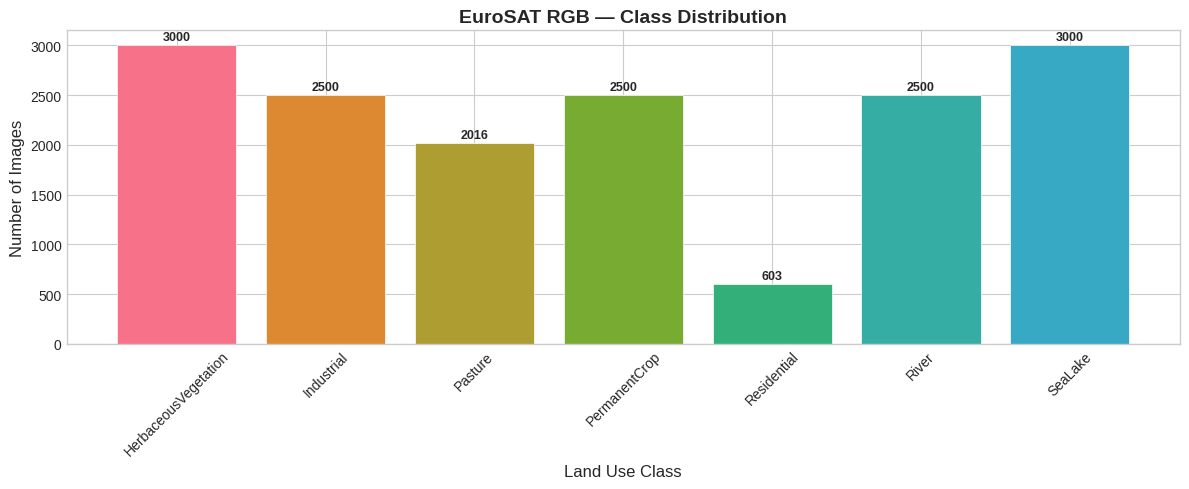

[✓] Class distribution plot saved


In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.style.use("seaborn-v0_8-whitegrid")

fig, ax = plt.subplots(figsize=(12, 5))
counts = df_all["class_name"].value_counts().sort_index()
colors = sns.color_palette("husl", n_colors=NUM_CLASSES)

bars = ax.bar(counts.index, counts.values, color=colors, edgecolor="white", linewidth=0.5)
ax.set_xlabel("Land Use Class", fontsize=12)
ax.set_ylabel("Number of Images", fontsize=12)
ax.set_title("EuroSAT RGB — Class Distribution", fontsize=14, fontweight="bold")
ax.tick_params(axis="x", rotation=45)

for bar, count in zip(bars, counts.values):
    ax.text(bar.get_x() + bar.get_width() / 2, bar.get_height() + 20,
            str(count), ha="center", va="bottom", fontsize=9, fontweight="bold")

plt.tight_layout()
fig.savefig(PROJECT_ROOT / "data" / "eda" / "class_distribution.png", dpi=150, bbox_inches="tight")
plt.show()
print("[✓] Class distribution plot saved")

In [ ]:
import os

for item in os.listdir(DATA_DIR):
    print(item)

label_map.json
train.csv
test.csv
validation.csv
SeaLake
River
Highway
Pasture
PermanentCrop
Industrial
Residential
HerbaceousVegetation
AnnualCrop
Forest


In [ ]:
print(CLASS_NAMES)
print(len(CLASS_NAMES))
print(len(df_all))
print(df_all["class_name"].value_counts().sort_index())

['AnnualCrop', 'Forest', 'HerbaceousVegetation', 'Highway', 'Industrial', 'Pasture', 'PermanentCrop', 'Residential', 'River', 'SeaLake']
10
16119
class_name
HerbaceousVegetation    3000
Industrial              2500
Pasture                 2016
PermanentCrop           2500
Residential              603
River                   2500
SeaLake                 3000
Name: count, dtype: int64


In [ ]:
for cls in ["AnnualCrop", "Forest", "Highway"]:
    class_dir = DATA_DIR / cls
    print(f"\n--- {cls} ---")
    print("Files in folder:")
    for i, f in enumerate(sorted(class_dir.iterdir())):
        print(f.name)
        if i >= 10:
            break


--- AnnualCrop ---
Files in folder:

--- Forest ---
Files in folder:

--- Highway ---
Files in folder:


In [1]:
for cls in ["AnnualCrop", "Forest", "Highway"]:
    class_dir = DATA_DIR / cls
    print(f"\n--- {cls} ---")

    for item in class_dir.iterdir():
        print(item)

NameError: name 'DATA_DIR' is not defined